# Differential accessibility between WT and KD within celltypes

In [3]:
here::i_am("rna_atac/dimensionality_reduction/WNN_MOFA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
      

In [60]:
args = list()
# RNA seurat 
args$rna_seurat = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/seurat_object.rds')
args$logFC_thr = 0.25
args$FDR_thr = 0.05
opts$min_cdr = 0.15
opts$groups = c('eomes_ko', 'wt')

cluster_levels = unique(opts$clusters2celltypes)

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/accessibility/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [61]:
plot_enr_heatmap = function(enrichMotifs, ntop=25) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)

    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] %>% .[,TF:=strsplit(TF, '_') %>% map_chr(1)]

    keep_tfs = enriched.dt %>% .[,variable:=factor(variable, levels=cluster_levels)] %>% .[order(variable)] %>% .[, head(.SD, ntop),  by=variable] %>% .$TF   
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(keep_tfs))] %>%
        .[,variable:=factor(variable, levels=cluster_levels)]
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') +
    scale_fill_gradient(low='white', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]') +
    theme_void() + theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=1),
                        legend.position='bottom')
p
    return(p)
}

#### Load ArchR

In [62]:
# Load seurat for clusters & annotate celltypes
seurat = readRDS(args$rna_seurat)
seurat@meta.data$celltypes_v1 = opts$clusters2celltypes[match(as.character(seurat@meta.data$seurat_clusters), names(opts$clusters2celltypes))]

In [63]:
meta = as.data.table(seurat@meta.data, keep.rownames=T) %>% 
    setnames('rn', 'cell') %>% 
    .[day!='D3'] %>% # remove D3 cells
    .[,celltype_genotype:=paste0(celltypes_v1, '-', genotype)]

In [64]:
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')
ArchRProject <- loadArchRProject(args$archr_directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [65]:
addArchRThreads(16)

Setting default number of Parallel threads to 16.



In [66]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$celltypes_v1),
                                    cells = meta$cell,
                                    name = "celltype_v1",
                                    force=TRUE)

ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$celltype_genotype),
                                    cells = meta$cell,
                                    name = "celltype_genotype",
                                    force=TRUE)


Overriding previous entry for celltype_genotype



In [67]:
atac.sce = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-2ac6f768bd199-Date-2023-02-26_Time-14-04-47.log
If there is an issue, please report to github with logFile!

2023-02-26 14:05:48 : Organizing colData, 1.027 mins elapsed.

2023-02-26 14:05:49 : Organizing rowData, 1.042 mins elapsed.

2023-02-26 14:05:49 : Organizing rowRanges, 1.043 mins elapsed.

2023-02-26 14:05:49 : Organizing Assays (1 of 1), 1.043 mins elapsed.

2023-02-26 14:06:42 : Constructing SummarizedExperiment, 1.914 mins elapsed.

2023-02-26 14:07:51 : Finished Matrix Creation, 3.07 mins elapsed.



In [68]:
summary(colnames(atac.sce) == meta$cell)

   Mode   FALSE    TRUE 
logical   28479       2 

In [69]:
atac.sce = atac.sce[,match(meta$cell, colnames(atac.sce))]
summary(colnames(atac.sce) == meta$cell)

   Mode    TRUE 
logical   28481 

In [70]:
peakSet = as.data.table(ArchRProject@peakSet) %>% 
    .[, feature:=paste0(seqnames, ':', start, '-', end)] %>%
    .[,idx:=1:nrow(.)] %>%
    .[,c('feature', 'idx')]
features = peakSet$feature

In [71]:
rownames(atac.sce) = features
atac.sce$celltype = meta$celltypes_v1
atac.sce$genotype = meta$genotype
atac.sce@assays@data$counts = atac.sce@assays@data$PeakMatrix

In [72]:
atac.mtx = atac.sce

In [73]:
DARs = mclapply(unique(opts$clusters2celltypes), function(ct, min_cells=25){ #args$celltypes
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (nrow(meta[celltype_genotype == paste0(ct, '-eomes_ko')]) < min_cells | nrow(meta[celltype_genotype == paste0(ct, '-wt')]) < min_cells) {
      out <- data.table(Log2FC=NA, Mean=NA, FDR=NA, Pval=NA, MeanDiff=NA, MeanBGD=NA, idx=NA, feature=NA, detection_rate_groupA=NA, detection_rate_groupB=NA)
      message('skipping ', ct, ' due to low cell number')
    } else {
        
        #stopifnot(opts$groups%in%atac.se$genotype)
        #atac.se$genotype <- factor(atac.se$genotype, levels=opts$groups)
        
        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate

        atac.mtx_tmp <- atac.mtx[,atac.mtx$celltype %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2)
        )
        
        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]
        message(ct, ' with ', length(features.to.use), ' regions')

        #ArchRProject.filt = ArchRProject[ArchRProject@cellColData$celltype==ct,]
        ##########################
        ## Differential testing ##
        ##########################
        
        # sometimes get errors, because of NA's in matrix? but ArchR doesn't allow me to subset the peakmatrix
        out <- suppressMessages(getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "binomial",
          binarize=TRUE,
          useGroups = paste0(ct, '-eomes_ko'),
          bgdGroups = paste0(ct, '-wt'),
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        ))
        
        # ArchR doesn't allow to select only specified features for differential testing, so instead I run it on everything 
        # Here I select only the relevant features and redo fdr correction.
        out = as.data.table(do.call("cbind", out@assays@data)) %>% 
            setnames(names(out@assays@data)) %>%
            .[,idx:=1:nrow(.)] %>%
            .[,feature := features] %>% 
            .[feature %in% features.to.use,] %>%
            .[,FDR := p.adjust(Pval, method = 'fdr')] %>%
            merge(., acc.dt, by='feature')
        
        
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}, mc.cores=12) %>%  rbindlist(.,  fill=TRUE) %>% 
    setnames(c('Log2FC', 'FDR'), c('logFC', 'padj_fdr'))

In [74]:
fwrite(DARs, file.path(args$outdir, 'DARs_ArchR.txt.gz'))

In [75]:
DARs = fread(file.path(args$outdir, 'DARs_ArchR.txt.gz'))

In [76]:
tail(DARs)

feature,logFC,Mean,padj_fdr,Pval,MeanDiff,MeanBGD,idx,detection_rate_groupA,detection_rate_groupB,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
chrX:99820267-99820867,1.04439412,0.1553398,0.003228811,8.406514e-05,0.082524272,0.07281553,237298,0.21,0.07,Endothelium
chrX:99820988-99821588,0.94753258,0.1262136,0.019662368,1.246132e-03,0.063106796,0.06310680,237299,0.16,0.06,Endothelium
chrX:99853310-99853910,0.38187064,0.2038835,0.274044580,7.462628e-02,0.048543689,0.15533981,237305,0.25,0.15,Endothelium
chrX:99975132-99975732,-0.02075856,0.3300971,1.000000000,9.343190e-01,-0.004854369,0.33495146,237310,0.41,0.32,Endothelium
chrX:99976062-99976662,0.58496250,0.1116505,0.226332879,5.512504e-02,0.038834951,0.07281553,237311,0.15,0.07,Endothelium
,NA,NA,NA,NA,NA,NA,NA,NA,NA,blood


In [77]:
ct = 'Primitive_Streak'
markers = suppressMessages(getMarkerFeatures(
          ArchRProj = ArchRProject, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "wilcoxon",
          binarize=FALSE,
          bias = c("TSSEnrichment", "log10(nFrags)"),
          useGroups = paste0(ct, '-eomes_ko'),
          bgdGroups = paste0(ct, '-wt'),
          verbose= FALSE))

In [78]:
table(DARs$celltype)


                       Allantois Allantois_Precursor_Tbx4+_Pitx1- 
                           51987                            70734 
                           blood                      Endothelium 
                               1                            53695 
                              HE                     HE_precursor 
                           70949                            60764 
        Mesenchyme_Podxl+_Foxf1+               Mesoderm_Eomes-_T+ 
                           57734                            49789 
         Mesoderm_Eomes+_PdgfRa+                  Mesoderm_Meis2+ 
                           49041                            53647 
 Posterior_Mesoderm_Cdx4+_Hoxa9+                 Primitive_Streak 
                           55385                            42767 

In [79]:
head(DARs)

feature,logFC,Mean,padj_fdr,Pval,MeanDiff,MeanBGD,idx,detection_rate_groupA,detection_rate_groupB,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
chr10:100015416-100016016,-0.14177396,0.51260504,0.2682552,0.04982718,-0.053221289,0.56582633,143105,0.30,0.21,Primitive_Streak
chr10:100016254-100016854,0.07895134,0.47058824,0.7074005,0.36521676,0.025210084,0.44537815,143106,0.18,0.11,Primitive_Streak
chr10:100486508-100487108,-0.24100810,0.02801120,0.8808617,0.60317800,-0.005602241,0.03361345,143129,0.21,0.14,Primitive_Streak
chr10:100487178-100487778,-0.58496250,0.01960784,0.5234470,0.19282121,-0.011204482,0.03081232,143130,0.60,0.45,Primitive_Streak
chr10:100588961-100589561,-0.28379297,0.06162465,0.6676832,0.32096944,-0.014005602,0.07563025,143134,0.22,0.16,Primitive_Streak
chr10:103027707-103028307,0.34958444,0.21848739,0.1845545,0.02378658,0.047619048,0.17086835,143166,0.17,0.11,Primitive_Streak


Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”


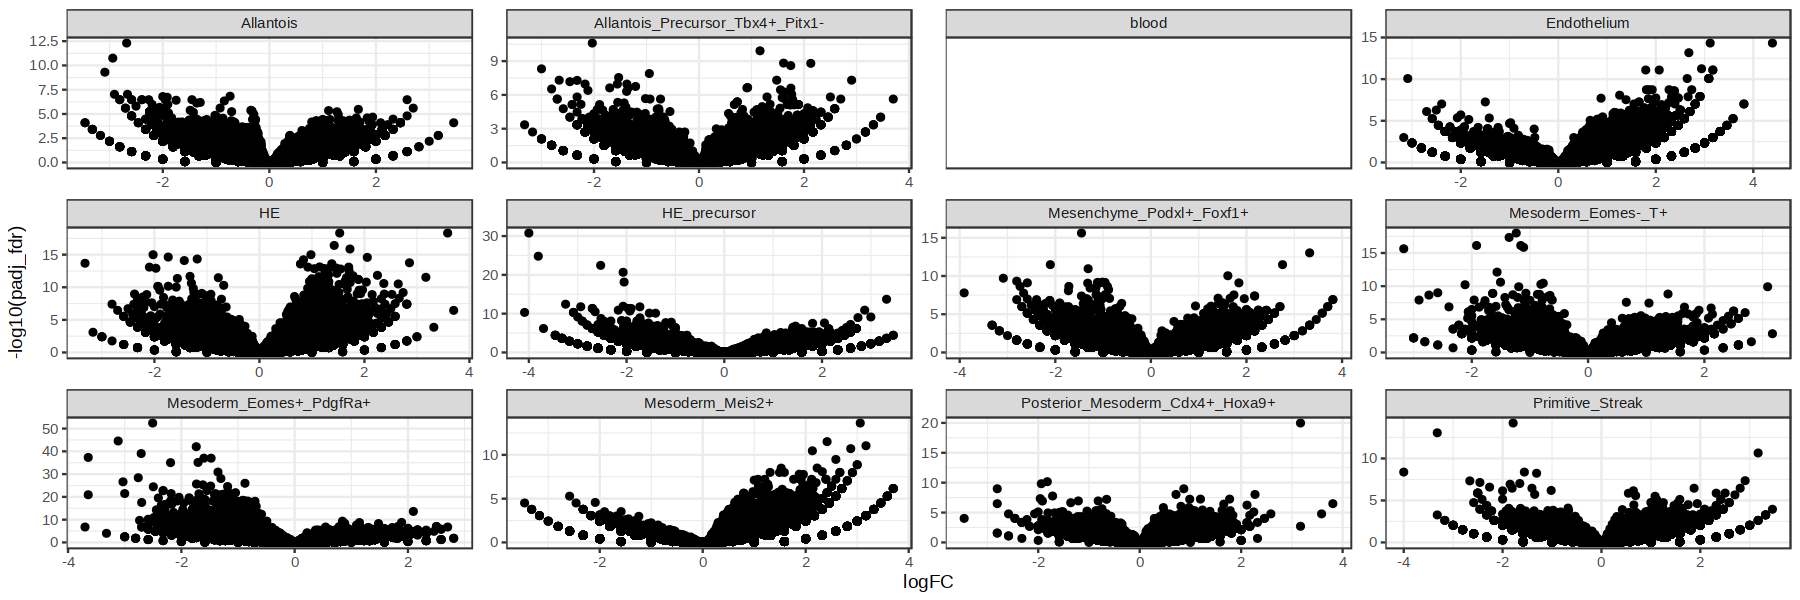

In [80]:
ggplot(DARs, aes(logFC, -log10(padj_fdr))) +
    geom_point() + 
    facet_wrap(~celltype, scales='free') + 
    theme_bw()

In [81]:
enrich_full = list()
for(i in unique(DARs$celltype)){
        tmp1 = merge(data.table(idx=1:nrow(peakSet)), DARs[celltype==i], by='idx', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

In [82]:
enrich_full

class: SummarizedExperiment 
dim: 238993 12 
metadata(24): MatchInfo Params ... MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(238993): 1 2 ... 238992 238993
rowData names(4): seqnames idx start end
colnames(12): Primitive_Streak Mesoderm_Eomes+_PdgfRa+ ... Endothelium
  blood
colData names(0):

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f6ef1930-Date-2023-02-26_Time-14-11-59.log
If there is an issue, please report to github with logFile!



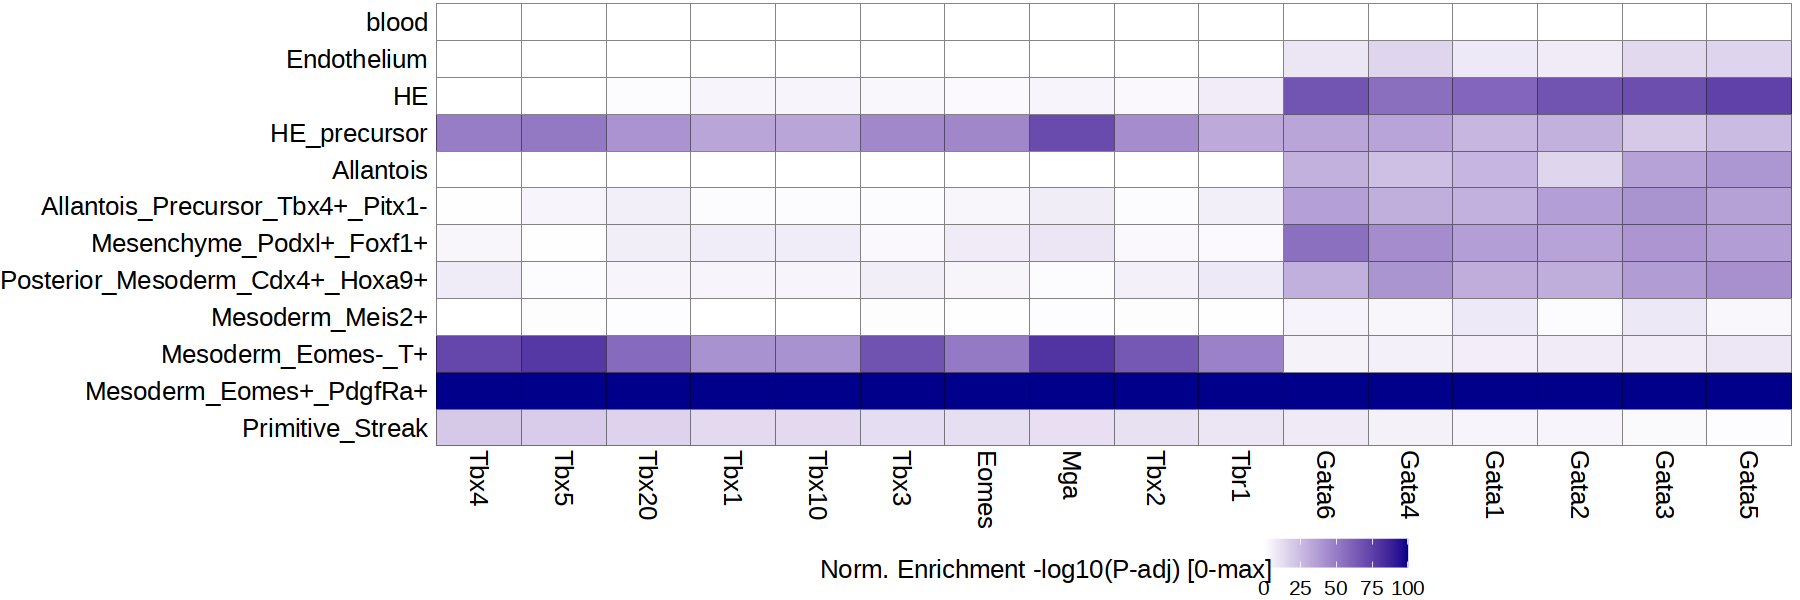

In [83]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f79494803-Date-2023-02-26_Time-14-12-20.log
If there is an issue, please report to github with logFile!



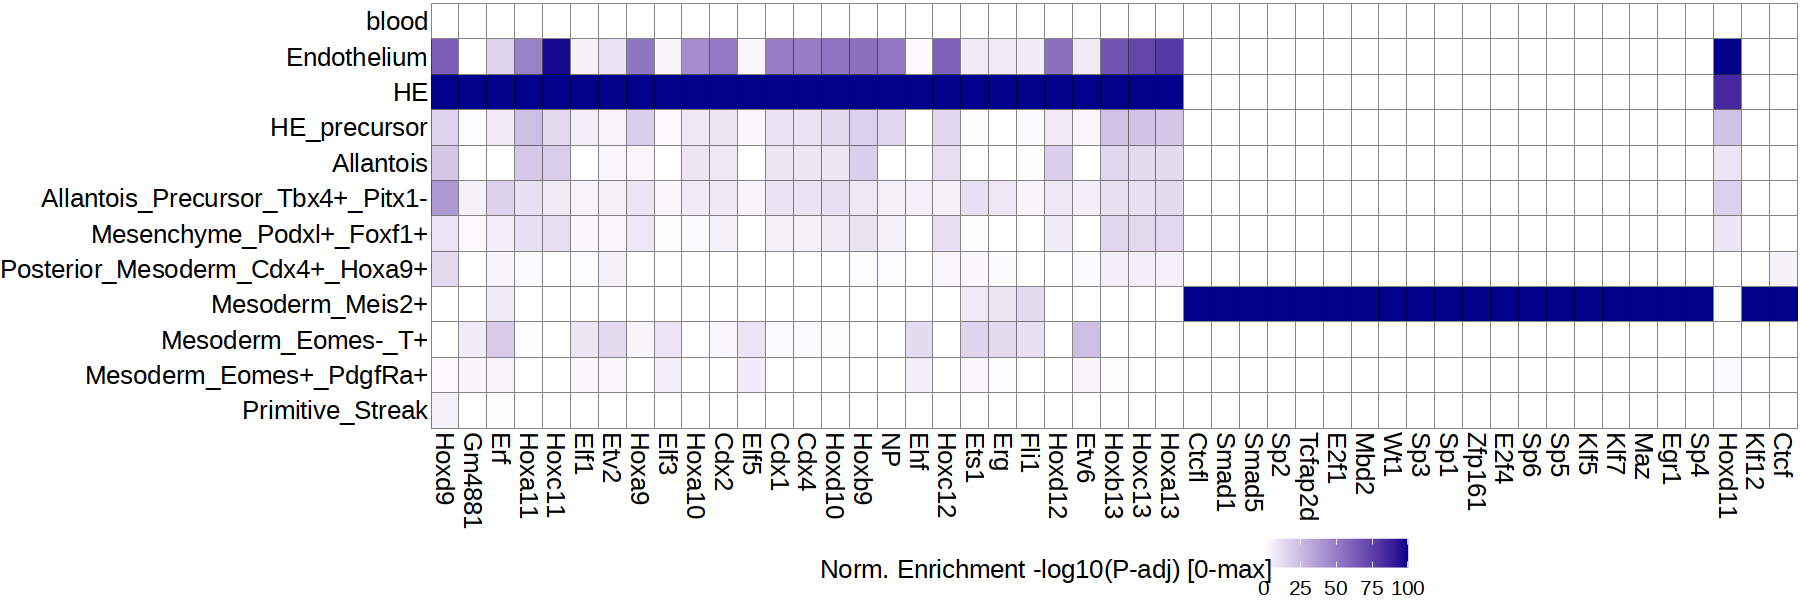

In [84]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >=0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6fb40cda6-Date-2023-02-26_Time-14-12-41.log
If there is an issue, please report to github with logFile!



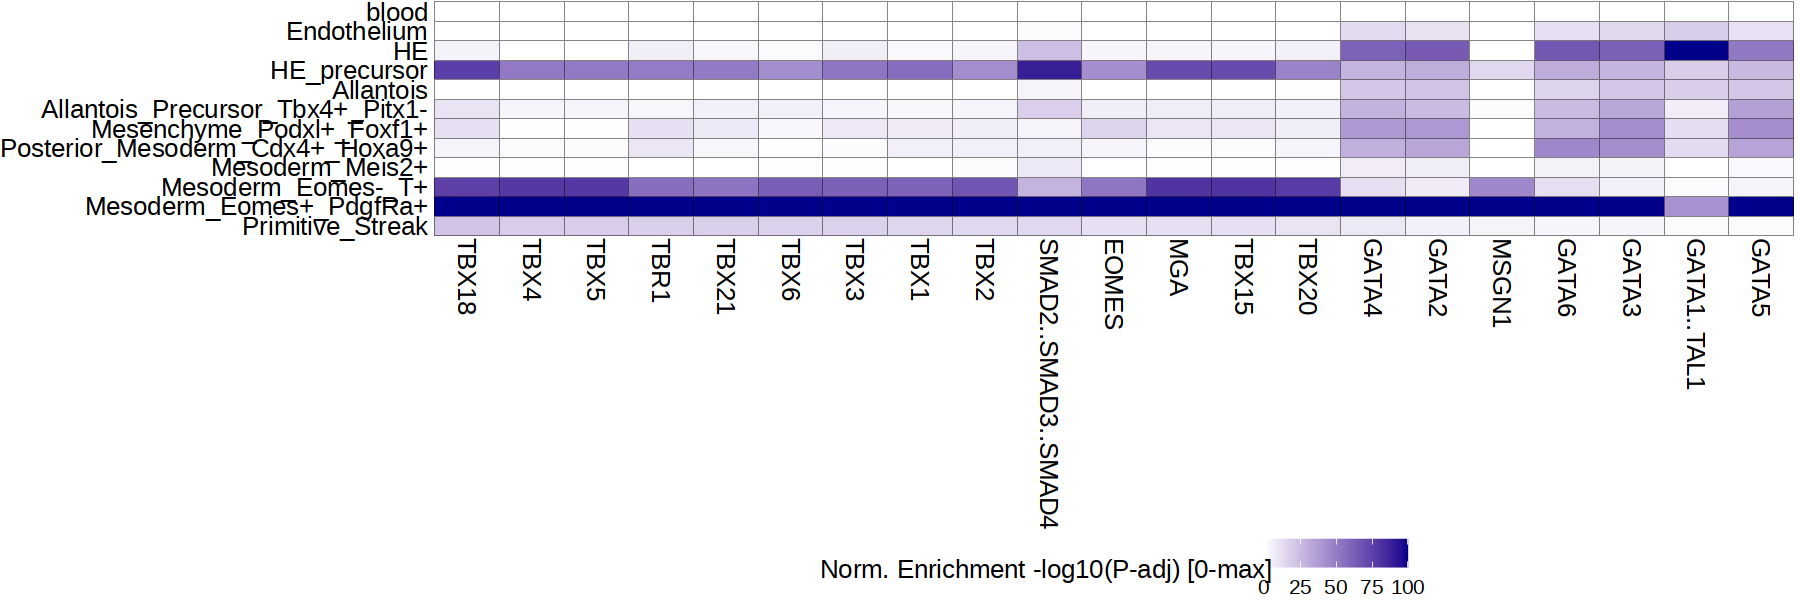

In [85]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f193d880d-Date-2023-02-26_Time-14-12-58.log
If there is an issue, please report to github with logFile!



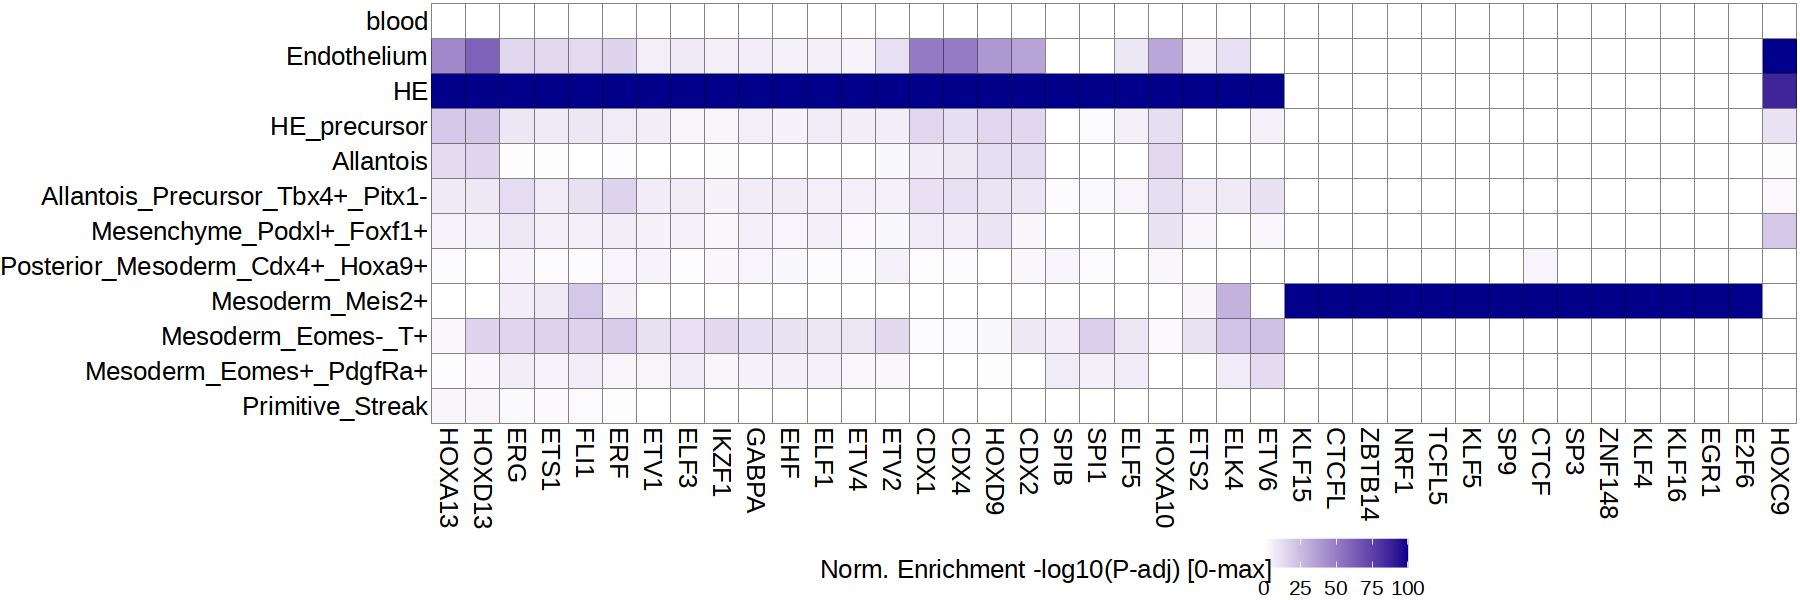

In [86]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC >=0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f568cff96-Date-2023-02-26_Time-14-13-18.log
If there is an issue, please report to github with logFile!



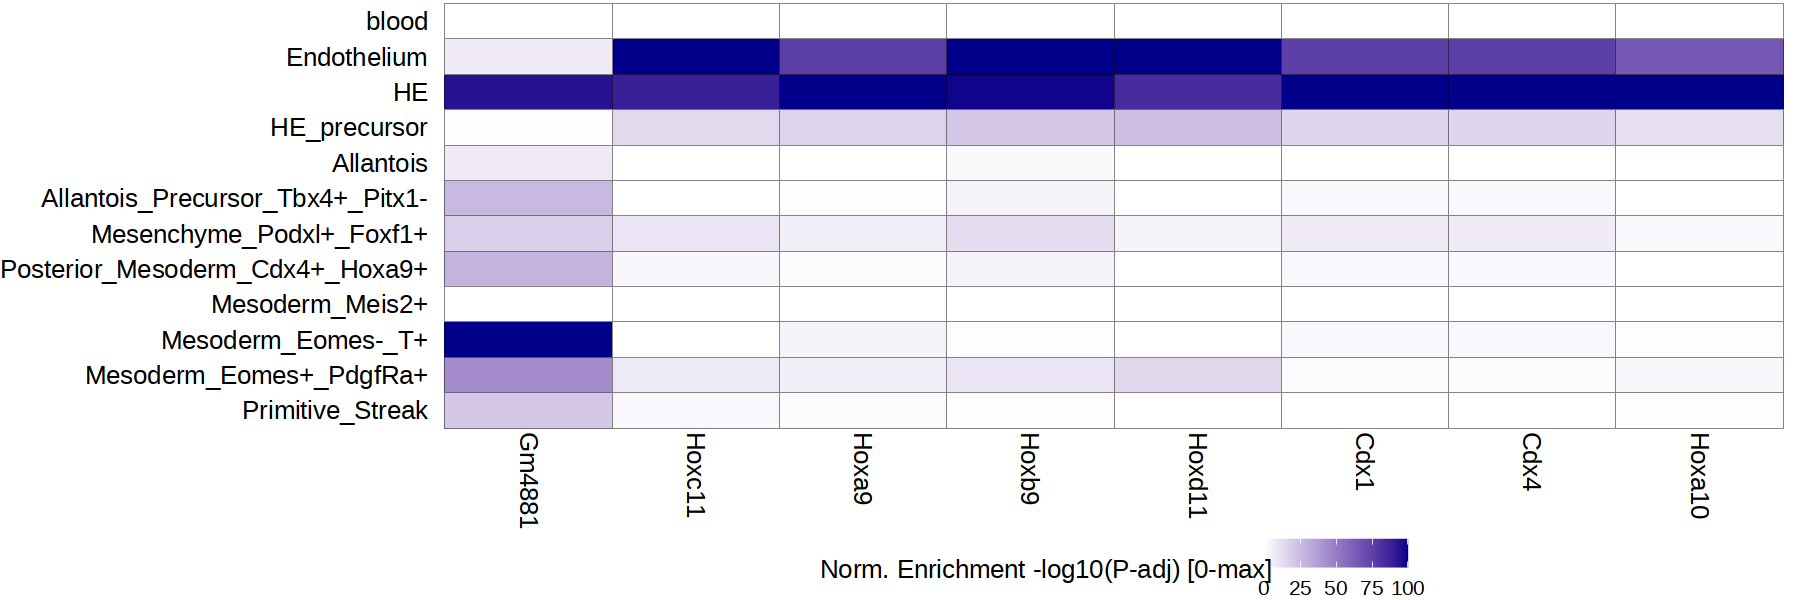

In [87]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >= 1"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 4)

In [88]:
DARs = mclapply(unique(opts$clusters2celltypes), function(ct, min_cells=25){ #args$celltypes
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (nrow(meta[celltype_genotype == paste0(ct, '-eomes_ko')]) < min_cells | nrow(meta[celltype_genotype == paste0(ct, '-wt')]) < min_cells) {
      out <- data.table(Log2FC=NA, Mean=NA, FDR=NA, Pval=NA, MeanDiff=NA, MeanBGD=NA, idx=NA, feature=NA, detection_rate_groupA=NA, detection_rate_groupB=NA)
      message('skipping ', ct, ' due to low cell number')
    } else {
        
        #stopifnot(opts$groups%in%atac.se$genotype)
        #atac.se$genotype <- factor(atac.se$genotype, levels=opts$groups)
        
        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate

        atac.mtx_tmp <- atac.mtx[,atac.mtx$celltype %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2)
        )
        
        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]
        message(ct, ' with ', length(features.to.use), ' regions')

        #ArchRProject.filt = ArchRProject[ArchRProject@cellColData$celltype==ct,]
        ##########################
        ## Differential testing ##
        ##########################
        
        # sometimes get errors, because of NA's in matrix? but ArchR doesn't allow me to subset the peakmatrix
        out <- suppressMessages(getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "wilcoxon",
          binarize=FALSE,
          useGroups = paste0(ct, '-eomes_ko'),
          bgdGroups = paste0(ct, '-wt'),
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        ))
        
        # ArchR doesn't allow to select only specified features for differential testing, so instead I run it on everything 
        # Here I select only the relevant features and redo fdr correction.
        out = as.data.table(do.call("cbind", out@assays@data)) %>% 
            setnames(names(out@assays@data)) %>%
            .[,idx:=1:nrow(.)] %>%
            .[,feature := features] %>% 
            .[feature %in% features.to.use,] %>%
            .[,FDR := p.adjust(Pval, method = 'fdr')] %>%
            merge(., acc.dt, by='feature')
        
        
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}, mc.cores=12) %>%  rbindlist(.,  fill=TRUE) %>% 
    setnames(c('Log2FC', 'FDR'), c('logFC', 'padj_fdr'))

Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”


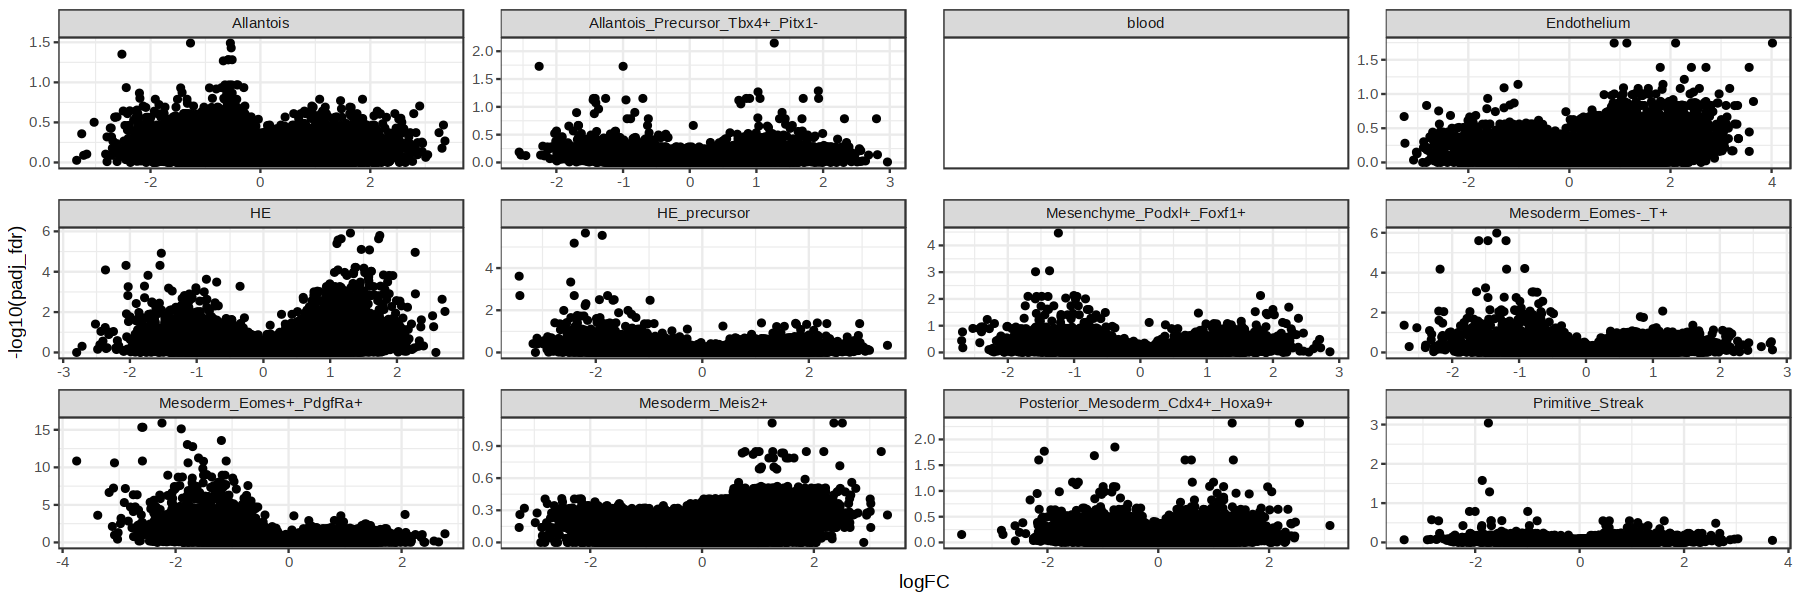

In [89]:
ggplot(DARs, aes(logFC, -log10(padj_fdr))) +
    geom_point() + 
    facet_wrap(~celltype, scales='free') + 
    theme_bw()

In [90]:
enrich_full = list()
for(i in unique(DARs$celltype)){
        tmp1 = merge(data.table(idx=1:nrow(peakSet)), DARs[celltype==i], by='idx', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

In [91]:
enrich_full

class: SummarizedExperiment 
dim: 238993 12 
metadata(24): MatchInfo Params ... MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(238993): 1 2 ... 238992 238993
rowData names(4): seqnames idx start end
colnames(12): Primitive_Streak Mesoderm_Eomes+_PdgfRa+ ... Endothelium
  blood
colData names(0):

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f4cfa3d5c-Date-2023-02-26_Time-14-19-50.log
If there is an issue, please report to github with logFile!



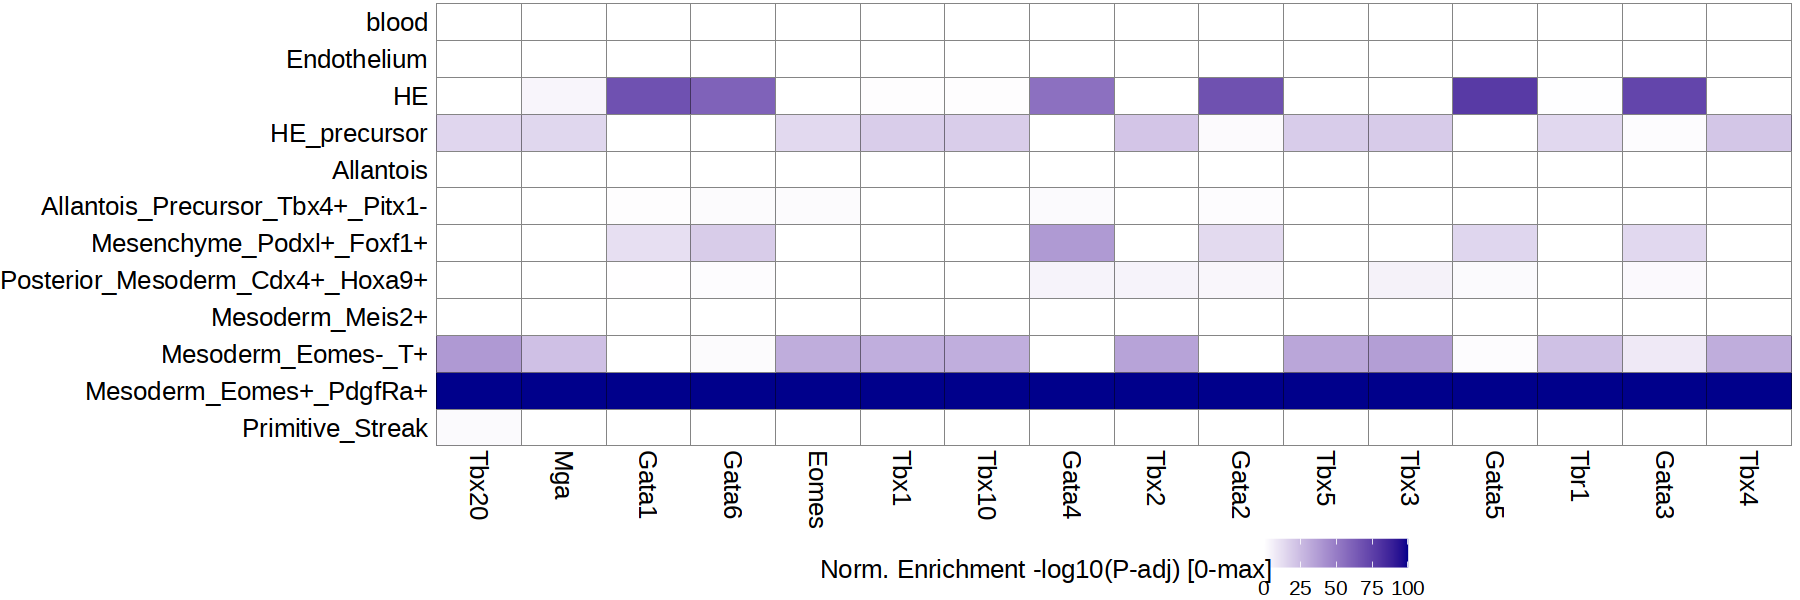

In [92]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f27c59f5b-Date-2023-02-26_Time-14-20-08.log
If there is an issue, please report to github with logFile!



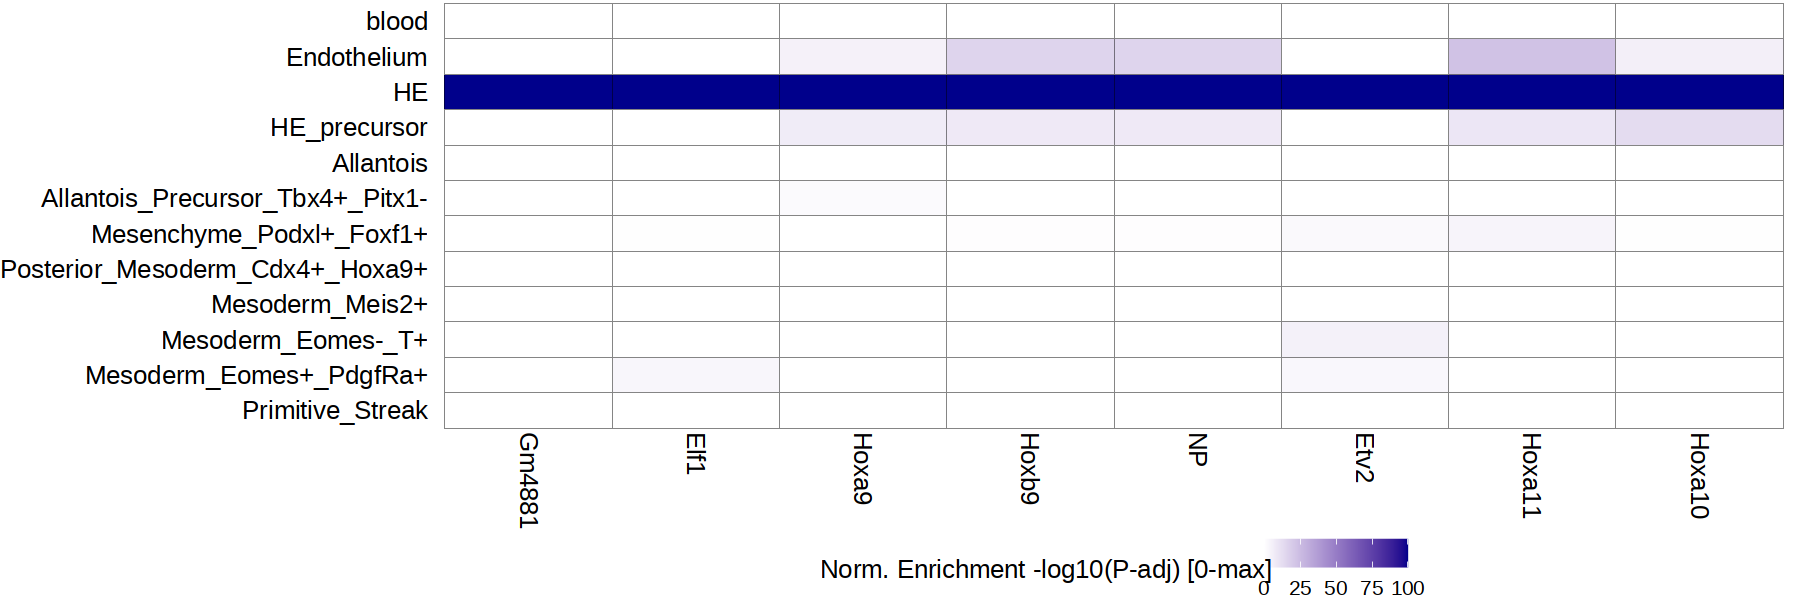

In [93]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >=0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f19918334-Date-2023-02-26_Time-14-20-24.log
If there is an issue, please report to github with logFile!



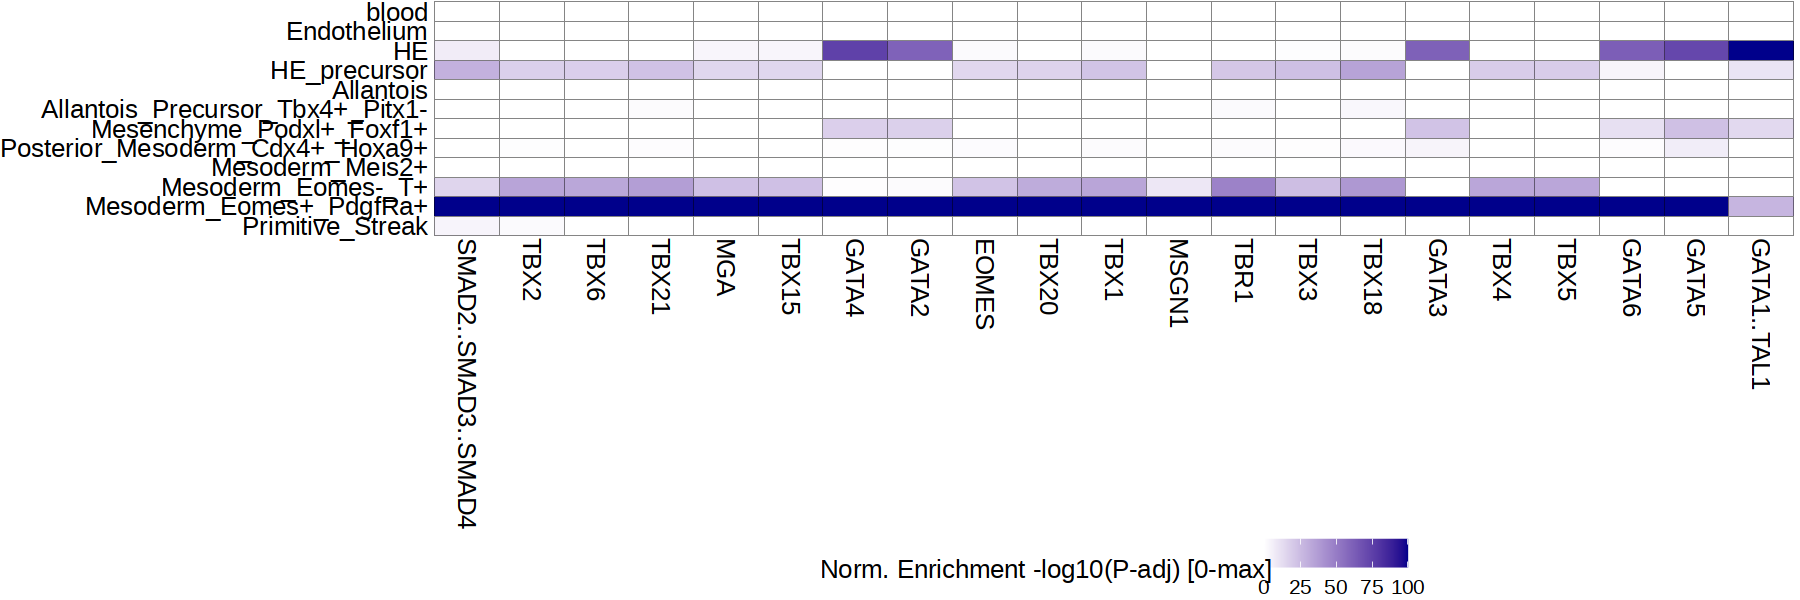

In [94]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-2ac6f35d6db92-Date-2023-02-26_Time-14-20-40.log
If there is an issue, please report to github with logFile!



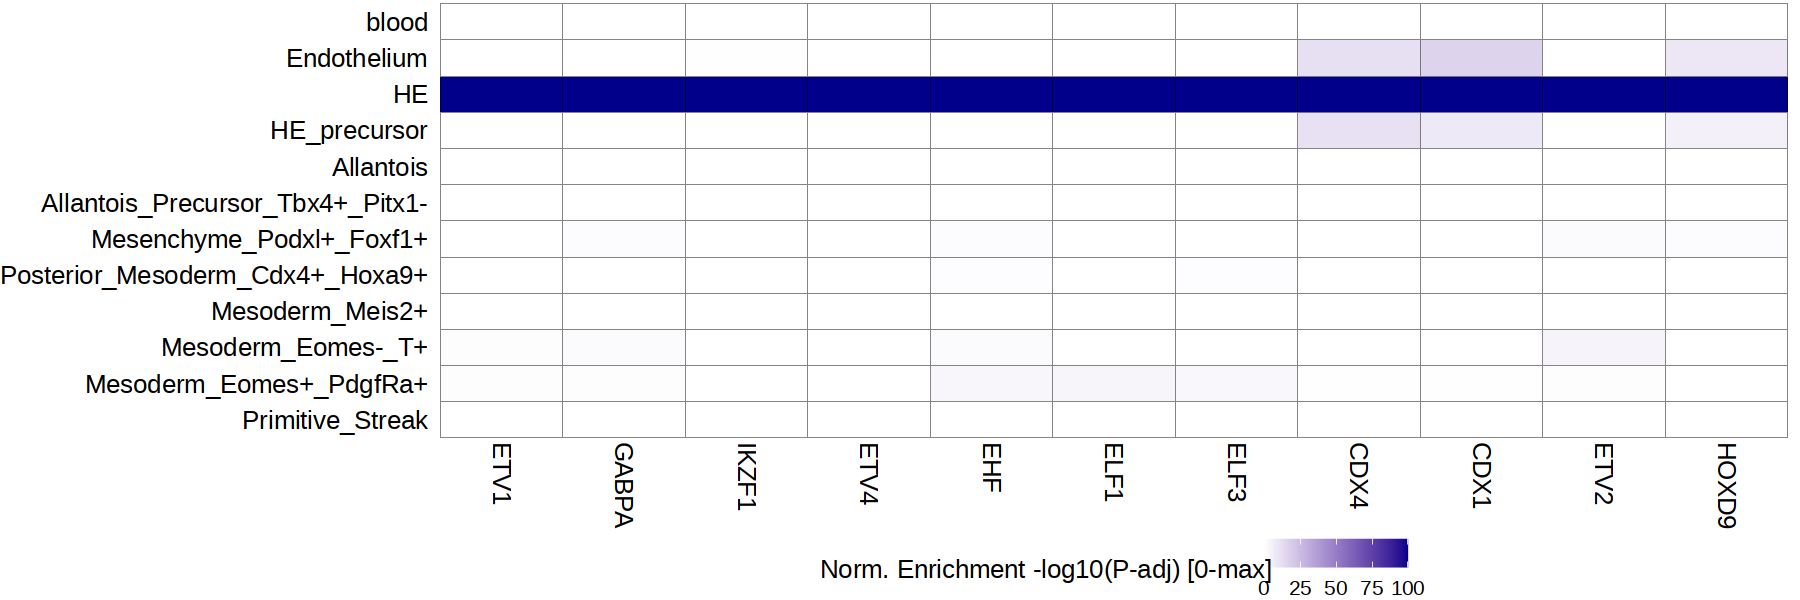

In [95]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC >=0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

In [96]:
head(meta)

cell,orig.ident,nCount_RNA,nFeature_RNA,barcode,sample,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,⋯,pass_atacQC,Clusters_TileMatrix0.5,Clusters_TileMatrix_genotype,Clusters_PeakMatrix_genotype,Clusters_PeakMatrix2,exp,RNA_snn_res.1.2,seurat_clusters,celltypes_v1,celltype_genotype
<chr>,<fct>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,⋯,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>,<chr>
2_Eo_DEG_G9_day3_5_VC#AAACAGCCAAAGCGGC-1,2,5243,2811,AAACAGCCAAAGCGGC-1,2_Eo_DEG_G9_day3_5_VC,3.43,8.03,day3.5_wt_rep2,D3.5,⋯,TRUE,C1,C1wt,C15wt,C15,exp2,8,8,Mesoderm_Eomes+_PdgfRa+,Mesoderm_Eomes+_PdgfRa+-wt
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1,2,13914,4688,AAACAGCCATGGAGGC-1,2_Eo_DEG_G9_day3_5_VC,12.33,7.05,day3.5_wt_rep2,D3.5,⋯,TRUE,C6,C6wt,C15wt,C15,exp2,18,18,Mesoderm_Meis2+,Mesoderm_Meis2+-wt
2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGTTGGC-1,2,8005,3582,AAACAGCCATGTTGGC-1,2_Eo_DEG_G9_day3_5_VC,5.36,6.68,day3.5_wt_rep2,D3.5,⋯,TRUE,C5,C5wt,C15wt,C15,exp2,0,0,Mesoderm_Eomes+_PdgfRa+,Mesoderm_Eomes+_PdgfRa+-wt
2_Eo_DEG_G9_day3_5_VC#AAACATGCACCACAAC-1,2,11058,4221,AAACATGCACCACAAC-1,2_Eo_DEG_G9_day3_5_VC,4.10,6.94,day3.5_wt_rep2,D3.5,⋯,TRUE,C5,C5wt,C15wt,C15,exp2,0,0,Mesoderm_Eomes+_PdgfRa+,Mesoderm_Eomes+_PdgfRa+-wt
2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1,2,10338,4014,AAACATGCAGAATGAC-1,2_Eo_DEG_G9_day3_5_VC,8.42,7.40,day3.5_wt_rep2,D3.5,⋯,TRUE,C1,C1wt,C17wt,C17,exp2,15,15,Mesoderm_Eomes-_T+,Mesoderm_Eomes-_T+-wt
2_Eo_DEG_G9_day3_5_VC#AAACATGCATGGAGGC-1,2,9165,3717,AAACATGCATGGAGGC-1,2_Eo_DEG_G9_day3_5_VC,9.17,8.34,day3.5_wt_rep2,D3.5,⋯,TRUE,C5,C5wt,C15wt,C15,exp2,8,8,Mesoderm_Eomes+_PdgfRa+,Mesoderm_Eomes+_PdgfRa+-wt


In [97]:
colnames(ArchRProject@cellColData)

[1] "Sample"                    "TSSEnrichment"            
 [3] "ReadsInTSS"                "ReadsInPromoter"          
 [5] "ReadsInBlacklist"          "PromoterRatio"            
 [7] "PassQC"                    "NucleosomeRatio"          
 [9] "nMultiFrags"               "nMonoFrags"               
[11] "nFrags"                    "nDiFrags"                 
[13] "BlacklistRatio"            "barcode"                  
[15] "sample"                    "nFeature_RNA"             
[17] "nCount_RNA"                "mitochondrial_percent_RNA"
[19] "ribosomal_percent_RNA"     "alias"                    
[21] "day"                       "genotype"                 
[23] "pass_rnaQC"                "doublet_score"            
[25] "doublet_call"              "celltype"                 
[27] "celltype.score"            "closest.cell"             
[29] "day_celltype"              "celltype_genotype"        
[31] "TSSEnrichment_atac"        "ReadsInTSS_atac"          
[33] "PromoterRatio_atac"        "NucleosomeRatio_atac"     
[35] "nFrags_atac"               "BlacklistRatio_atac"      
[37] "ReadsInPeaks"              "FRIP"                     
[39] "celltype_v1"

In [122]:
unique(meta$day)

[1] "D3"   "D3.5" "D4"   "D5"   "D4.5"

In [38]:
meta = meta %>% 
    .[,cluster_genotype:=paste0(seurat_clusters, '-', genotype)]

ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$cluster_genotype),
                                    cells = meta$cell,
                                    name = "cluster_genotype",
                                    force=TRUE)

atac.mtx$seurat_clusters = meta$seurat_clusters

Overriding previous entry for cluster_genotype



In [39]:
DARs = mclapply(unique(meta$seurat_clusters), function(ct, min_cells=25){ #args$celltypes
    tmp <- sprintf("%s-%s",ct,opts$groups)
    if (nrow(meta[cluster_genotype == paste0(ct, '-eomes_ko')]) < min_cells | nrow(meta[cluster_genotype == paste0(ct, '-wt')]) < min_cells) {
      out <- data.table(Log2FC=NA, Mean=NA, FDR=NA, Pval=NA, MeanDiff=NA, MeanBGD=NA, idx=NA, feature=NA)
      message('skipping ', ct, ' due to low cell number')
    } else {
        
        #stopifnot(opts$groups%in%atac.se$genotype)
        #atac.se$genotype <- factor(atac.se$genotype, levels=opts$groups)
        
        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate

        atac.mtx_tmp <- atac.mtx[,atac.mtx$seurat_clusters %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2)
        )
        
        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]
        message(ct, ' with ', length(features.to.use), ' regions')

        #ArchRProject.filt = ArchRProject[ArchRProject@cellColData$celltype==ct,]
        ##########################
        ## Differential testing ##
        ##########################
        
        # sometimes get errors, because of NA's in matrix? but ArchR doesn't allow me to subset the peakmatrix
        out <- suppressMessages(getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix",
          groupBy = "cluster_genotype",
          testMethod = "wilcoxon",
          binarize=FALSE,
          useGroups = paste0(ct, '-eomes_ko'),
          bgdGroups = paste0(ct, '-wt'),
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        ))
        
        # ArchR doesn't allow to select only specified features for differential testing, so instead I run it on everything 
        # Here I select only the relevant features and redo fdr correction.
        out = as.data.table(do.call("cbind", out@assays@data)) %>% 
            setnames(names(out@assays@data)) %>%
            .[,idx:=1:nrow(.)] %>%
            .[,feature := features] %>% 
            .[feature %in% features.to.use,] %>%
            .[,FDR := p.adjust(Pval, method = 'fdr')]
        
        
    }
    out = out %>% .[,seurat_clusters:=ct]
    return(out)
}, mc.cores=12)# %>%  rbindlist(.,  fill=TRUE) %>% 
  #  setnames(c('Log2FC', 'FDR'), c('logFC', 'padj_fdr'))


In [42]:
DARs = DARs %>%  rbindlist(.,  fill=TRUE) %>% 
    setnames(c('Log2FC', 'FDR'), c('logFC', 'padj_fdr'))

Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”


ERROR: Error in eval(expr, envir, enclos): object 'markers' not found


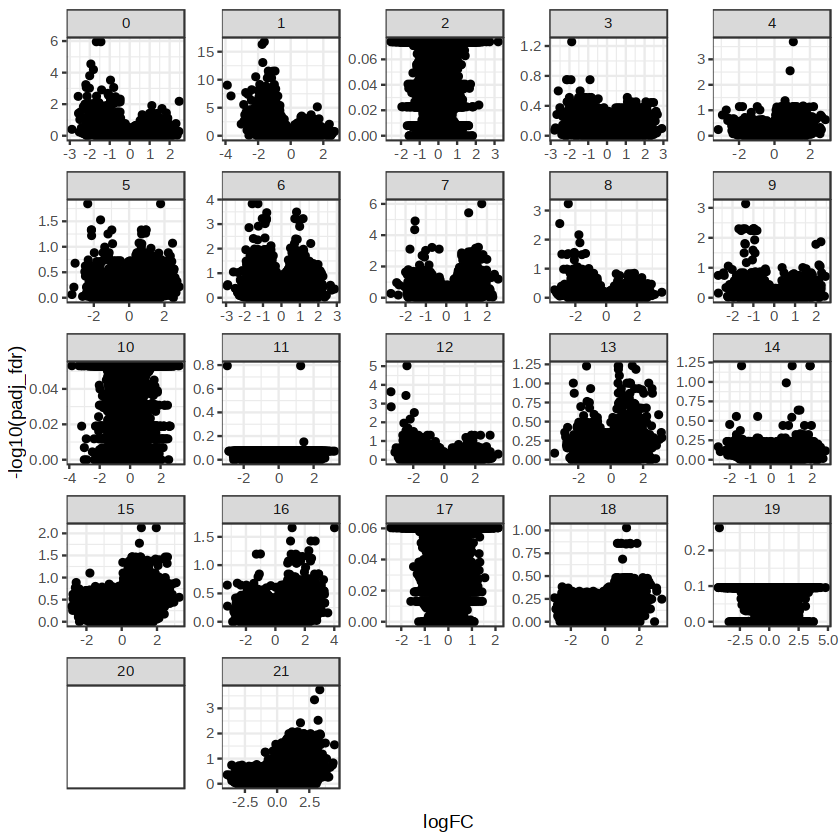

In [43]:




ggplot(DARs, aes(logFC, -log10(padj_fdr))) +
    geom_point() + 
    facet_wrap(~seurat_clusters, scales='free') + 
    theme_bw()



In [44]:
ct = 'Primitive_Streak'
markers = suppressMessages(getMarkerFeatures(
          ArchRProj = ArchRProject, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "wilcoxon",
          binarize=FALSE,
          bias = c("TSSEnrichment", "log10(nFrags)"),
          useGroups = paste0(ct, '-eomes_ko'),
          bgdGroups = paste0(ct, '-wt'),
          verbose= FALSE))

In [45]:

enrich_full = list()
for(i in unique(DARs$seurat_clusters)){
        tmp1 = merge(data.table(idx=1:nrow(peakSet)), DARs[seurat_clusters==i], by='idx', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.05 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 4)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-28c9f3595d9a5-Date-2023-02-26_Time-11-55-39.log
If there is an issue, please report to github with logFile!



ERROR: Error in plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE): No enrichments found for your cutoff!
